# Linear Regression

This is my implementation using Linear Regression in housing price prediction. I used training data from [Kaggle-Housing Price Dataset](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset).

For detail, I proposed a linear function to predict housing price with 3 features: area, number of bedrooms, and number of bathrooms. 

To have a deep understand about this machine learning model, I implemented **Gradient Descent** method by Stochastic algorithm to get optimal function, and determined exact root by **Normal Equation** method (as small dataset). Then I checked those results with given model in **Scikit-learn** library. 

## Preparing Dataset

First of all, I used Pandas library to load dataset from Kaggle and print some lines to check.

In [4]:
import kagglehub
import os
import pandas as pd

# 1. Prepare dataset:
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
print(f"Path to dataset files: {path}")
print(os.listdir(path))

df = pd.read_csv(f"{path}/Housing.csv")

print(f"Data frame shape: {df.shape}")
print(df.head(3)) # Fist 3 lines of data frame to check

Path to dataset files: /home/leatuyrbertyk/.cache/kagglehub/datasets/yasserh/housing-prices-dataset/versions/1
['Housing.csv']
Data frame shape: (545, 13)
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  


## Normal Equation and model from Scikit-learn

Source code below is my implementation for **Normal Equation** and model from **Scikit-learn** library.

In [ ]:
import kagglehub
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Prepare dataset:
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
df = pd.read_csv(f"{path}/Housing.csv")

m = df.shape[0]

X = df[['area', 'bedrooms', 'bathrooms']].values
y = df['price'].values

# 2. Normalize dataframe due to its large scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 3. Normal equation:
X_bias = np.concatenate((np.ones((m,1)), X), axis = 1) # Add a column filled by 1 at the left of data frame
theta_normal = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
theta_normal = theta_normal.reshape(-1, 1)

# 4. Scikit-learn:
model = LinearRegression()
model.fit(X, y)

theta_sklearn = np.concatenate((model.intercept_.reshape(-1,1),model.coef_.reshape(-1,1)), axis = 0)

# 5. Result:
print(f"Normal Equation:\n{theta_normal}")
print(f"Scikit-learn:\n{theta_sklearn}")

Normal Equation:
[[4766729.24770642]
 [ 821214.14349519]
 [ 299983.57107963]
 [ 695808.52272537]]
Scikit-learn:
[[4766729.24770642]
 [ 821214.14349519]
 [ 299983.57107963]
 [ 695808.52272537]]


As this is a small dataset, **Normal Equation** can compute the exact root promptly in spite of its disadvantages about time complexity. We can see that, those two model give the same result.

## Stochastic Gradient descent

With the harder, I implemented **Stochastic Gradient Descent** method below:

Data frame shape: (545, 13)
Stochastic Gradient Descent:
 [[4764816.64423294]
 [ 820946.02816388]
 [ 299813.79135254]
 [ 695413.50677538]]


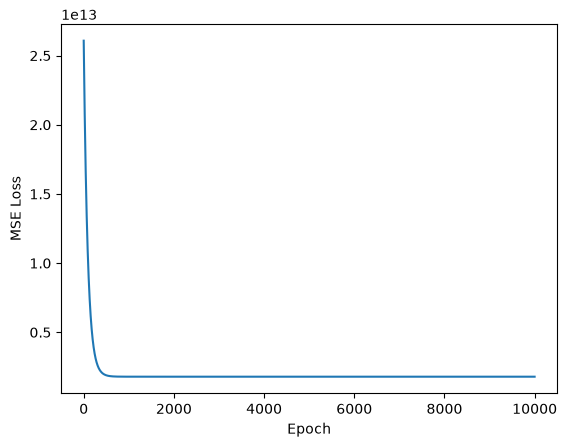

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def stochastic_linear_regression(X, y, epochs = 10000, learning_rate = 1e-5):
    (m, n) = X.shape
    theta = np.zeros(n)
    losses = []

    for _ in range(epochs):
        total_loss = 0
        for i in range(0, m):
            prediction = np.dot(theta, X[i])
            error = prediction - y[i, 0]
            theta = theta - learning_rate*error*X[i]

            total_loss += error**2
        losses.append(total_loss/m)

    return (theta, losses)

# 1. Prepare dataset:
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
df = pd.read_csv(f"{path}/Housing.csv")

print(f"Data frame shape: {df.shape}")
m = df.shape[0]

X = df[['area', 'bedrooms', 'bathrooms']].values
y = df['price'].values.reshape(-1, 1)

# 2. Normalize dataframe due to its large scale:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_bias = np.concatenate((np.ones((m, 1)), X), axis = 1)

# 3. Result:
(theta_stochastic, losses) = stochastic_linear_regression(X_bias, y, 10000, 1e-5)
theta_stochastic = theta_stochastic.reshape(-1, 1)

print(f"Stochastic Gradient Descent:\n {theta_stochastic}")

# 4. Plot the Losses:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

The result of **Stochastic Gradient Descent** is quite different from the result of **Normal Equation** and model from **Scikit-learn** libeary. But it is normal, as this is only a basic implementation of the model, and the result also depends on `learning_rate`, `epochs`. So we need to test and run many times to get the ideal values.

Furthermore, I also plotted the graph of MSE losses over epoch. As you can see, with some first epoch, the average error are very high, then it decreases singificantly and almost have the same value when epoch attaches to 10000.